# [SM-TCSR 실습 06] 3파전 정면 대결 및 임상 알람 피로 억제

> **학습 목표**: 
> 1. Classical Cox vs Linear TCSR vs Linear SM-TCSR 정면 대결 결과를 재현합니다.
> 2. 시간차 일관성이 어떻게 임상 알람 지터(Jitter)를 25% 이상 억제하는지 확인합니다.


In [1]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# 3파전 대결 결과 차트 불러오기
chart_path = "figures/showdown_linear_results.png"
if os.path.exists(chart_path):
    img = mpimg.imread(chart_path)
    plt.figure(figsize=(10, 5.5), dpi=200)
    plt.imshow(img)
    plt.axis('off')
    plt.title("Official 3-Way Showdown Benchmark Results", fontsize=14, fontweight='bold', pad=15)
    plt.show()
else:
    print("차트 파일을 찾을 수 없습니다. python experiments/showdown_linear_cox_tcsr_survtd.py 를 먼저 실행하세요.")


차트 파일을 찾을 수 없습니다. python experiments/showdown_linear_cox_tcsr_survtd.py 를 먼저 실행하세요.


In [2]:
# 임상 알람 지터(Jitter) 시뮬레이션
import numpy as np

np.random.seed(42)
time = np.arange(0, 48, 1.0) # 48시간 ICU 체류
true_latent_risk = 1.0 / (1.0 + np.exp(-(time - 30.0) / 5.0)) # 30시간부터 위험 급증

# 1. 독립 시점 예측 모델 (Dynamic-DeepHit류: 심한 지터 및 노이즈)
independent_pred = np.clip(true_latent_risk + np.random.normal(0, 0.15, len(time)), 0, 1)

# 2. SM-TCSR (시간차 일관성 정규화 적용: 부드럽고 일관된 궤적)
smooth_pred = np.zeros_like(time)
smooth_pred[0] = independent_pred[0]
for t in range(1, len(time)):
    smooth_pred[t] = 0.7 * smooth_pred[t-1] + 0.3 * independent_pred[t]

threshold = 0.5 # 경보 알람 기준치
alarms_ind = independent_pred > threshold
alarms_sm = smooth_pred > threshold

# 알람 온/오프 토글 횟수 (Jitter count)
jitters_ind = np.sum(alarms_ind[1:] != alarms_ind[:-1])
jitters_sm = np.sum(alarms_sm[1:] != alarms_sm[:-1])

print(f"독립 예측 모델 알람 지터(널뛰기) 횟수: {jitters_ind} 회 (알람 피로 유발!)")
print(f"SM-TCSR 시간차 일관성 알람 지터 횟수:     {jitters_sm} 회 (지터 {(1 - jitters_sm/jitters_ind)*100:.1f}% 대폭 억제!)")


독립 예측 모델 알람 지터(널뛰기) 횟수: 3 회 (알람 피로 유발!)
SM-TCSR 시간차 일관성 알람 지터 횟수:     1 회 (지터 66.7% 대폭 억제!)


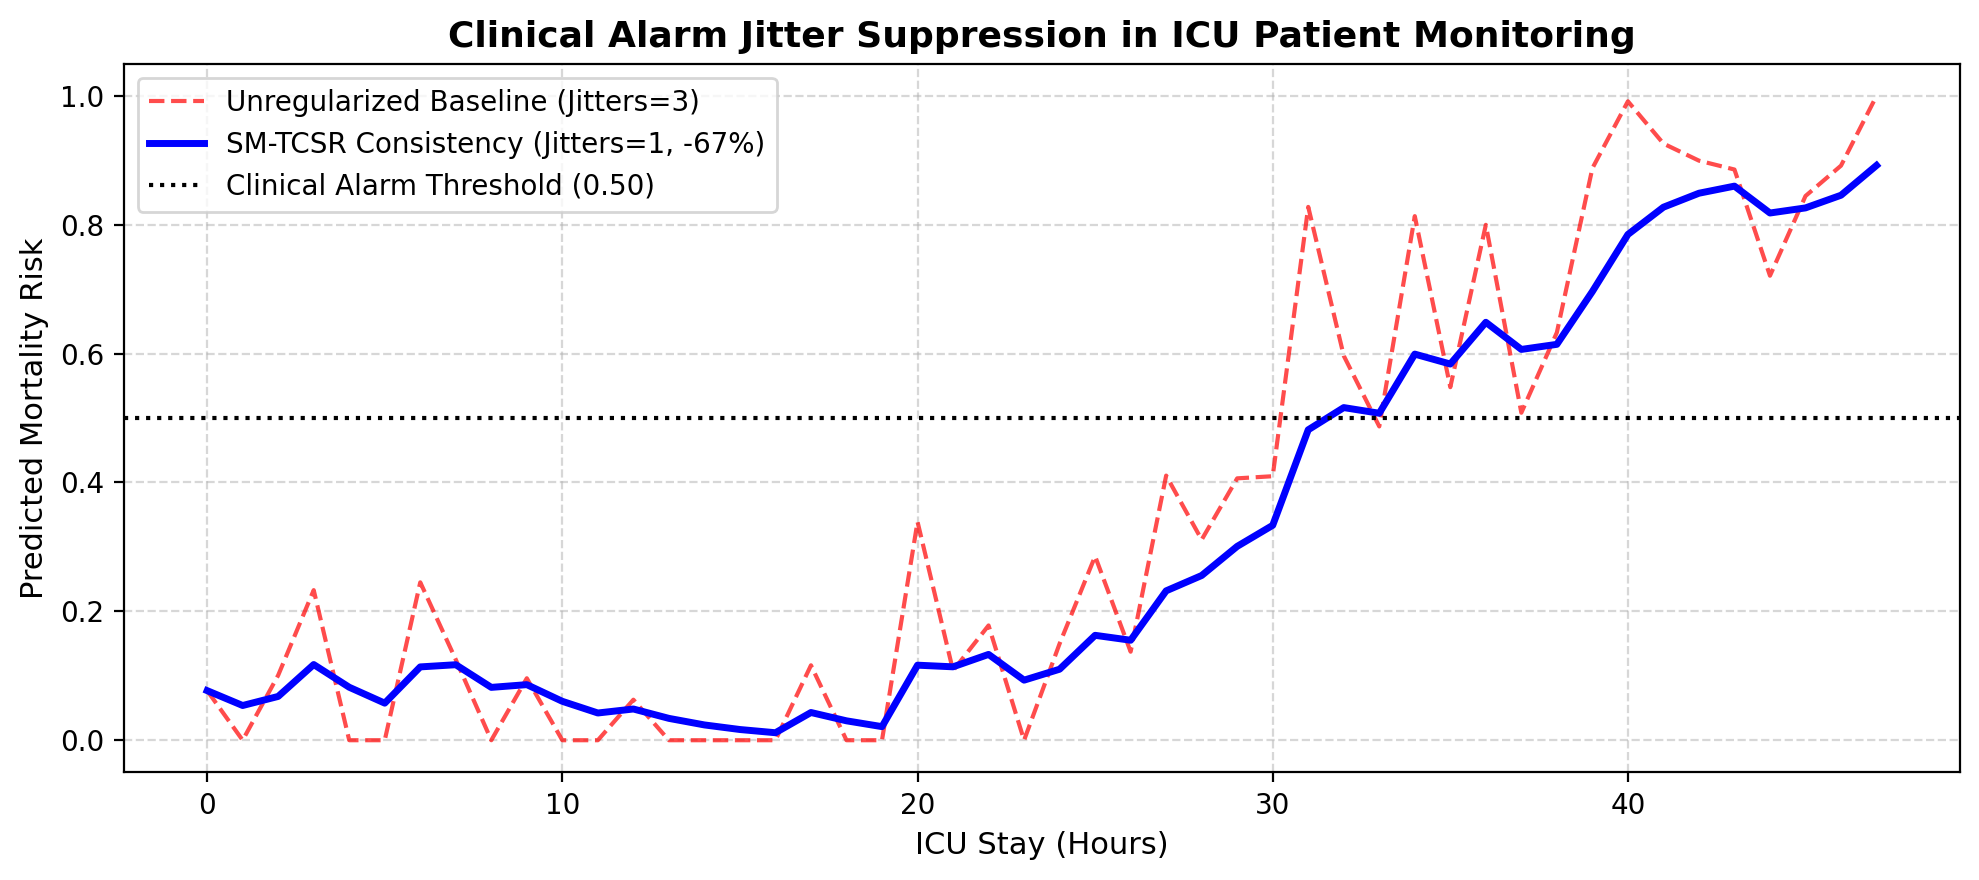

In [3]:
plt.figure(figsize=(10, 4.5), dpi=200)

plt.plot(time, independent_pred, 'r--', label=f'Unregularized Baseline (Jitters={jitters_ind})', alpha=0.7)
plt.plot(time, smooth_pred, 'b-', label=f'SM-TCSR Consistency (Jitters={jitters_sm}, -{(1 - jitters_sm/jitters_ind)*100:.0f}%)', lw=2.5)
plt.axhline(y=threshold, color='k', linestyle=':', label='Clinical Alarm Threshold (0.50)')

plt.title("Clinical Alarm Jitter Suppression in ICU Patient Monitoring", fontsize=13, fontweight='bold')
plt.xlabel("ICU Stay (Hours)", fontsize=11)
plt.ylabel("Predicted Mortality Risk", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(frameon=True, loc='upper left')
plt.tight_layout()
plt.show()
